# Long term memory

In [81]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langgraph.store.memory import InMemoryStore
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore
import uuid


In [82]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
store = InMemoryStore(index={'embed': embeddings, 'dims': 1536})

In [83]:
user_ns = ('memory', 'user_alpha')
store.put(user_ns, 'm1', {'fact': 'Working on learning LangGraph'})
store.put(user_ns, 'm2', {'fact': 'Prefers concise explanations'})

In [84]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

In [85]:
def chat_node(state: AgentState, config: RunnableConfig, store: BaseStore): # <--- Updated type hint

    # 1. Extract user_id securely from the config
    user_id = config["configurable"].get("user_id", "default_user")
    namespace = ("memory", user_id)
    last_message = state["messages"][-1].content

    # 2. Recall memory using the injected store
    memories = store.search(namespace, query=last_message, limit=2)

    if memories:
        memory_text = "\n".join([f"- {m.value['fact']}" for m in memories])
    else:
        memory_text = "No prior memories found."

    # 3. Build Prompt
    system_msg = SystemMessage(
        content=f"You are a helpful AI tutor. Here is what you know about the user:\n{memory_text}\n\nUse this information to personalize your answer."
    )

    messages_to_pass = [system_msg] + state["messages"]

    # 4. Generate Response
    response = llm.invoke(messages_to_pass)

    # 5. Save New Memory
    memory_id = str(uuid.uuid4())
    store.put(namespace, memory_id, {"fact": last_message})

    return {"messages": [response]}

In [86]:
builder = StateGraph(AgentState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

app = builder.compile(store=store)

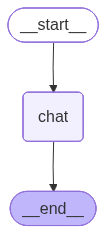

In [87]:
app

In [88]:
# Create the execution configuration
thread_config = {"configurable": {"user_id": "user_alpha"}}

# The user asks a question
user_input = "Can you give me a breakdown of how the 'StateGraph' works?"

# Run the graph
result = app.invoke(
    {"messages": [HumanMessage(content=user_input)]},
    config=thread_config
)

print(result["messages"][-1].content)

`StateGraph` is the core building block in LangGraph for defining stateful, multi-step workflows.

Here's a concise breakdown:

1.  **Shared State**:
    *   You define a single, shared state object (often a `TypedDict`) that all nodes can read from and write to.
    *   Each node receives the current state, processes it, and returns updates to merge into the global state.

2.  **Nodes**:
    *   These are the individual steps or functions in your workflow.
    *   Each node takes the current state as input and returns a dictionary of updates to that state.
    *   Nodes don't directly modify the state; they return changes that LangGraph merges.

3.  **Edges**:
    *   These define the flow between nodes.
    *   **Direct Edges**: Go from one node directly to another.
    *   **Conditional Edges**: After a node, a "router" function determines the next node based on the *current state*. This allows for dynamic branching.

4.  **Entry/Exit**:
    *   You specify a starting node (`set_ent